In [158]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [159]:
Train = pd.read_csv("Train.csv")
Train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [160]:
Train.shape

(8523, 12)

In [161]:
Train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [162]:
# fill the missing values of Item_Weight Based on the Item_Identifier Column
item_weight_mean = Train.pivot_table(values="Item_Weight" , index = "Item_Identifier")
item_weight_mean

,Item_Weight
Item_Identifier,
DRA12,11.600
DRA24,19.350
DRA59,8.270
DRB01,7.390
DRB13,6.115
...,...
NCZ30,6.590
NCZ41,19.850
NCZ42,10.500


In [163]:
# We need to check which row has the missing values and store it
miss_bool = Train["Item_Weight"].isnull()
miss_bool

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Item_Weight, Length: 8523, dtype: bool

In [164]:
# Now lets fill the missing values
for i, item in enumerate(Train["Item_Identifier"]):
    if miss_bool[i]:
      if item in item_weight_mean :
        Train["Item_Weight"][i] = item_weight_mean.loc[item]["Item_weight"]
      else:
        Train["Item_Weight"][i] = np.mean(Train["Item_Weight"])

In [165]:
Train["Item_Weight"].isna().sum()

0

In [166]:
# fill the missing values of Outlet_Size Based on the Outlet_Type
outlet_size_mode = Train.pivot_table(values="Outlet_Size", columns ="Outlet_Type", aggfunc =(lambda x: x.mode()[0]))
outlet_size_mode

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [167]:
# now lets fill the missing values
miss_bool = Train["Outlet_Size"].isnull()
Train.loc[miss_bool , "Outlet_Size"] = Train.loc[miss_bool , "Outlet_Type"].apply(lambda x: outlet_size_mode[x])

In [168]:
Train["Outlet_Size"].isna().sum()

0

In [169]:
sum(Train["Item_Visibility"]==0)

526

In [170]:
# replace zeros with mean value of Item_visibility
Train.loc[:,"Item_Visibility"].replace([0], [Train["Item_Visibility"].mean()], inplace = True)

In [171]:
sum(Train["Item_Visibility"]==0)

0

In [172]:
# LF,low fat = Low Fat
# reg = Regular
Train = Train.replace(to_replace = "low fat",value = "Low Fat")
Train = Train.replace(to_replace = "LF" , value= "Low Fat")
Train = Train.replace(to_replace = "reg" , value = "Regular")

In [173]:
Train["Item_Fat_Content"].value_counts()

Low Fat    5517
Regular    3006
Name: Item_Fat_Content, dtype: int64

In [174]:
Train["New_Item_Type"] =Train["Item_Identifier"].apply(lambda x: x[:2])
Train["New_Item_Type"]

0       FD
1       DR
2       FD
3       FD
4       NC
        ..
8518    FD
8519    FD
8520    NC
8521    FD
8522    DR
Name: New_Item_Type, Length: 8523, dtype: object

In [175]:
Train["New_Item_Type"] = Train["New_Item_Type"].replace({"FD":"Food" , "DR":"Drinks", "NC":"Non-Consumable"})
Train["New_Item_Type"].value_counts()

Food              6125
Non-Consumable    1599
Drinks             799
Name: New_Item_Type, dtype: int64

In [176]:
Train.loc[Train["New_Item_Type"] == "Non-Consumable","Item_Fat_Content"] = "Non- Edible"
Train["Item_Fat_Content"].value_counts()

Low Fat        3918
Regular        3006
Non- Edible    1599
Name: Item_Fat_Content, dtype: int64

In [177]:
# Create small values for establishent year
Train["Outlet_Years"] = 2013 - Train["Outlet_Establishment_Year"]

In [178]:
Train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Food,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Drinks,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Food,14
3,FDX07,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Food,15
4,NCD19,8.93,Non- Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable,26


In [179]:
df = Train

In [180]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Food,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Drinks,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Food,14
3,FDX07,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Food,15
4,NCD19,8.93,Non- Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable,26


In [181]:
# Item_Outlet_Sales is very much right Skewd so we need to normalize it using Log Transformation
Train["Item_Outlet_Sales"] = np.log(1+Train["Item_Outlet_Sales"])

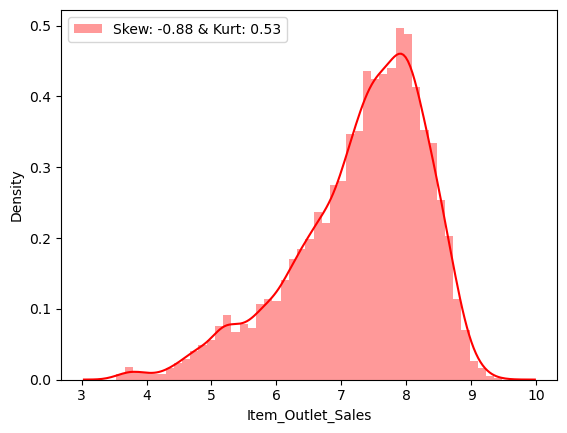

In [182]:
# After applying log transformation
sns.distplot(Train["Item_Outlet_Sales"], hist = True , color = "red" , label=f'Skew: {Train["Item_Outlet_Sales"].skew():.2f} & Kurt: {Train["Item_Outlet_Sales"].kurt():.2f}')
plt.legend()

In [183]:
Q1 = Train['Item_Visibility'].quantile(0.25)
Q3 = Train['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = Train[(Train['Item_Visibility'] < lower_bound) | (Train['Item_Visibility'] > upper_bound)]

In [184]:
outliers.shape

(173, 14)

In [185]:
Train = Train.drop(outliers.index)

In [186]:
q1 = Train['Item_Outlet_Sales'].quantile(0.25)
q3 = Train['Item_Outlet_Sales'].quantile(0.75)
IQR_s = q3 - q1

lower_bound = q1 - 1.5 * IQR_s
upper_bound = q3 + 1.5 * IQR_s

outlier = Train[(Train['Item_Outlet_Sales'] < lower_bound) | (Train['Item_Outlet_Sales'] > upper_bound)]

In [187]:
outlier.shape

(200, 14)

In [188]:
Train = Train.drop(outlier.index)

In [189]:
Train.shape

(8150, 14)

In [190]:
Train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.225808,Food,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.096776,Drinks,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.648868,Food,14
3,FDX07,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,6.597664,Food,15
4,NCD19,8.93,Non- Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.903451,Non-Consumable,26


In [191]:
Train.to_csv("data_clean.csv",index=False)

In [192]:
from pickle import dump
from pickle import load

In [193]:
Train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.225808,Food,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.096776,Drinks,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.648868,Food,14
3,FDX07,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,6.597664,Food,15
4,NCD19,8.93,Non- Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.903451,Non-Consumable,26


In [194]:
X = Train.drop(columns =["Outlet_Establishment_Year","Item_Identifier","Outlet_Identifier","Item_Outlet_Sales"])
y = Train["Item_Outlet_Sales"]

In [195]:
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,New_Item_Type,Outlet_Years
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,Food,14
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,Drinks,4
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,Food,14
3,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,Small,Tier 3,Grocery Store,Food,15
4,8.93,Non- Edible,0.066132,Household,53.8614,High,Tier 3,Supermarket Type1,Non-Consumable,26


In [196]:
X.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'New_Item_Type', 'Outlet_Years'],
      dtype='object')

In [197]:
#label encoder


In [198]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [199]:
# Create a dictionary to store label encoders for each column
label_encoders = {}

# List of categorical columns
cat_cols = ["Item_Fat_Content", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type", "New_Item_Type", "Item_Type"]

# Apply LabelEncoder for each column
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Now you can use the individual label encoders for inverse_transform
original_classes = label_encoders["Outlet_Location_Type"].inverse_transform(X["Outlet_Location_Type"])

# Print the original classes
print("Original Outlet Location Type:", original_classes)

Original Outlet Location Type: ['Tier 1' 'Tier 3' 'Tier 1' ... 'Tier 2' 'Tier 3' 'Tier 1']


In [200]:
original_classes = label_encoders["Item_Fat_Content"].inverse_transform(X["Item_Fat_Content"])
original_classes

array(['Low Fat', 'Regular', 'Low Fat', ..., 'Non- Edible', 'Regular',
       'Low Fat'], dtype=object)

In [201]:
np.unique(original_classes)

array(['Low Fat', 'Non- Edible', 'Regular'], dtype=object)

In [202]:
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,New_Item_Type,Outlet_Years
0,9.30,0,0.016047,4,249.8092,1,0,1,1,14
1,5.92,2,0.019278,14,48.2692,1,2,2,0,4
2,17.50,0,0.016760,10,141.6180,1,0,1,1,14
3,19.20,2,0.066132,6,182.0950,2,2,0,1,15
4,8.93,1,0.066132,9,53.8614,0,2,1,2,26


In [203]:
for col, le in label_encoders.items():
    # Save the LabelEncoder to a file (you can use joblib or pickle)
    le_filename = f"{col}_label_encoder.sav"
    with open(le_filename, 'wb') as le_file:
        dump(le, le_file)

In [204]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8150 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Weight           8150 non-null   float64
 1   Item_Fat_Content      8150 non-null   int32  
 2   Item_Visibility       8150 non-null   float64
 3   Item_Type             8150 non-null   int32  
 4   Item_MRP              8150 non-null   float64
 5   Outlet_Size           8150 non-null   int32  
 6   Outlet_Location_Type  8150 non-null   int32  
 7   Outlet_Type           8150 non-null   int32  
 8   New_Item_Type         8150 non-null   int32  
 9   Outlet_Years          8150 non-null   int64  
dtypes: float64(3), int32(6), int64(1)
memory usage: 509.4 KB


In [205]:
y

0       8.225808
1       6.096776
2       7.648868
3       6.597664
4       6.903451
          ...   
8518    7.929984
8519    6.310436
8520    7.085159
8521    7.521100
8522    6.642056
Name: Item_Outlet_Sales, Length: 8150, dtype: float64

Standardized


In [206]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[-0.83841074, -0.99861968, -1.18696423, ..., -0.32721447,
        -0.18278828, -0.10895289],
       [-1.63243168,  1.23822254, -1.11077127, ...,  0.96671951,
        -2.09514317, -1.30842073],
       [ 1.08791226, -0.99861968, -1.17015525, ..., -0.32721447,
        -0.18278828, -0.10895289],
       ...,
       [-0.53301807,  0.11980143, -0.73562002, ..., -0.32721447,
         1.72956662, -0.70868681],
       [-1.32938819,  1.23822254,  1.85926243, ...,  0.96671951,
        -0.18278828, -1.30842073],
       [ 0.45363517, -0.99861968, -0.5070585 , ..., -0.32721447,
        -2.09514317,  0.13094068]])

In [207]:
dump(scaler,open("s_c.sav","wb"))

In [208]:
scaled_X = pd.DataFrame(scaled_X, columns=X.columns)

In [209]:
scaled_X

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,New_Item_Type,Outlet_Years
0,-0.838411,-0.998620,-1.186964,-0.770473,1.729529,-0.625433,-1.390320,-0.327214,-0.182788,-0.108953
1,-1.632432,1.238223,-1.110771,1.605820,-1.523977,-0.625433,1.099486,0.966720,-2.095143,-1.308421
2,1.087912,-0.998620,-1.170155,0.655303,-0.017026,-0.625433,-1.390320,-0.327214,-0.182788,-0.108953
3,1.487272,1.238223,-0.005843,-0.295214,0.636403,0.828025,1.099486,-1.621148,-0.182788,0.010994
4,-0.925330,0.119801,-0.005843,0.417674,-1.433701,-2.078891,1.099486,-0.327214,1.729567,1.330409
...,...,...,...,...,...,...,...,...,...,...
8145,-1.410435,-0.998620,-0.226307,1.368191,1.159876,-2.078891,1.099486,-0.327214,-0.182788,1.330409
8146,-1.054535,1.238223,-0.457437,-1.720990,-0.557195,0.828025,-0.145417,-0.327214,-0.182788,-0.468793
8147,-0.533018,0.119801,-0.735620,0.180044,-0.929048,0.828025,-0.145417,-0.327214,1.729567,-0.708687
8148,-1.329388,1.238223,1.859262,1.368191,-0.638295,-0.625433,1.099486,0.966720,-0.182788,-1.308421


Model Buiding

In [210]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

In [211]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [212]:
X_train,X_test,y_train,y_test = train_test_split(scaled_X,y,test_size = 0.3,random_state = 110)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((5705, 10), (2445, 10), (5705,), (2445,))

In [213]:
# build the model
model = RandomForestRegressor(n_estimators= 600 , min_samples_split= 10 , min_samples_leaf= 4 , max_depth= 10 , random_state = 110)
# train the model on training data
model.fit(X_train , y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=600, random_state=110)

In [214]:
feature_importance = model.feature_importances_

In [215]:
dump(model,open("RF_model.sav","wb"))

In [216]:
m1 = load(open("RF_model.sav","rb"))

In [217]:
m1

RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=600, random_state=110)

In [218]:
# feature_importance = model.feature_importances_

In [219]:
imp_fut = pd.DataFrame({"Future _Names":X.columns,"feature_importance":feature_importance,})
imp_fut.sort_values(ascending=False,by="feature_importance")

,Future _Names,feature_importance
4,Item_MRP,0.468130
7,Outlet_Type,0.425188
9,Outlet_Years,0.031895
2,Item_Visibility,0.031297
0,Item_Weight,0.019948
3,Item_Type,0.012296
1,Item_Fat_Content,0.003941
6,Outlet_Location_Type,0.003180
8,New_Item_Type,0.002296
5,Outlet_Size,0.001830


In [220]:
#cv = cross_val_score(model,X,y,cv=7)

In [221]:
#cv

In [222]:
#cv.mean()*100

In [223]:
pred_test = model.predict(X_test)
s_test = r2_score(y_test,pred_test)
s_test

0.6759075267067586

In [224]:
pred_train = model.predict(X_train)
s_train = r2_score(y_train,pred_train)
s_train

0.7499998723089026

In [225]:
m1.predict(X_test)

array([8.12778558, 8.16891183, 6.97693098, ..., 6.04408277, 7.75564097,
       6.58504593])

In [226]:
m1.predict(X_test.iloc[2,:].values.reshape(1,-1))

array([6.97693098])

In [227]:

X_test.iloc[2,:]

Item_Weight             0.030784
Item_Fat_Content       -0.998620
Item_Visibility         2.064653
Item_Type              -1.008102
Item_MRP               -1.063421
Outlet_Size             0.828025
Outlet_Location_Type   -0.145417
Outlet_Type            -0.327214
New_Item_Type          -0.182788
Outlet_Years           -0.468793
Name: 5010, dtype: float64

In [228]:


# Assuming X_test.iloc[2,:] is a Pandas Series
X_test_row = X_test.iloc[2, :].to_numpy().reshape(1, -1)

# Now you can use scaler.inverse_transform
result = scaler.inverse_transform(X_test_row)

In [229]:
result 

array([[13.        ,  0.        ,  0.15393011,  3.        , 76.7986    ,
         2.        ,  1.        ,  1.        ,  1.        , 11.        ]])

In [230]:
X_test["Item_Type"].value_counts()

 1.368191    354
-0.295214    338
 0.417674    273
-0.532844    253
-0.770473    195
-1.720990    183
-1.008102    176
 0.180044    151
 1.605820    130
 0.655303    119
-1.483361     77
-0.057585     64
 0.892932     52
-1.245731     30
 1.843449     30
 1.130561     20
Name: Item_Type, dtype: int64

In [231]:
original_classes = label_encoders["Item_Fat_Content"].inverse_transform(X["Item_Fat_Content"])
original_classes

array(['Low Fat', 'Regular', 'Low Fat', ..., 'Non- Edible', 'Regular',
       'Low Fat'], dtype=object)

In [232]:
x = "Low Fat"

In [233]:
y = [[17.50,0,0.016760,10,141.6180,1,0,1,1,14]]

In [234]:
scaler.transform(y)

array([[ 1.08791226, -0.99861968, -1.17015702,  0.65530276, -0.01702624,
        -0.62543283, -1.39032016, -0.32721447, -0.18278828, -0.10895289]])

In [235]:
model.predict(scaler.transform(y))

array([7.60810312])

In [236]:
np.exp(model.predict(scaler.transform(y))) - 1

array([2013.45329575])

In [237]:
# Define categorical columns
cat_cols = ["Item_Fat_Content", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type", "New_Item_Type", "Item_Type"]

# Load the label encoders
loaded_label_encoders = {}
for col in cat_cols:
    le_filename = f"{col}_label_encoder.sav"
    with open(le_filename, 'rb') as le_file:
        loaded_label_encoders[col] = load(le_file)

# Dummy data for a single input
df_new = pd.DataFrame({
    'Item_Fat_Content': ['Low Fat'],
    'Outlet_Size': ['Medium'],
    'Outlet_Location_Type': ['Tier 2'],
    'Outlet_Type': ['Supermarket Type1'],
    'New_Item_Type': ['Food'],
    'Item_Type': ["Meat"]
    # Add other columns...
})

# Transform the new data using the loaded LabelEncoders
for col, le in loaded_label_encoders.items():
    if col in df_new.columns:  # Check if the column exists in the new data
        df_new[col] = le.transform(df_new[col])

# Now df_new is transformed and ready for prediction
print(df_new)

   Item_Fat_Content  Outlet_Size  Outlet_Location_Type  Outlet_Type  \
0                 0            1                     1            1   

   New_Item_Type  Item_Type  
0              1         10  


In [238]:
scaler.get_feature_names_out()

array(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'New_Item_Type', 'Outlet_Years'], dtype=object)